In [1]:
# ==================== INSTALL & IMPORTS ====================
%pip install statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


Note: you may need to restart the kernel to use updated packages.


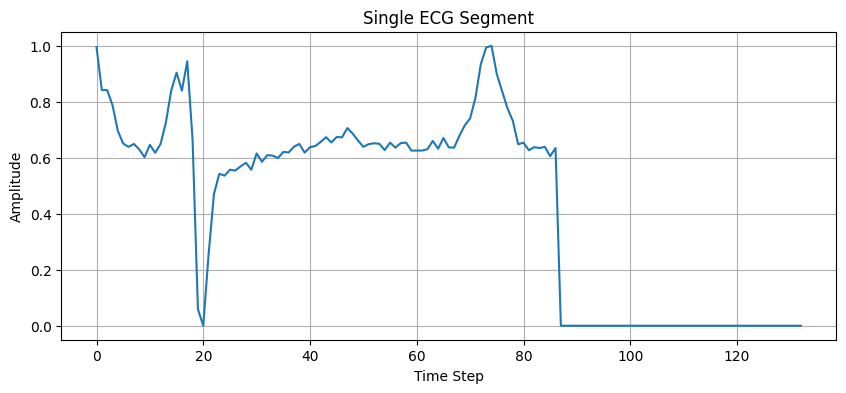

In [2]:
# ==================== SELECT SAMPLE TIME SERIES ====================
%run CleanData.ipynb
# Use the first ECG sample
ecg_series = X_train.iloc[0] if isinstance(X_train, pd.DataFrame) else pd.Series(X_train[0].flatten())

# Plot original ECG series
plt.figure(figsize=(10, 4))
plt.plot(ecg_series)
plt.title("Single ECG Segment")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


In [3]:
# ==================== FIT ARIMA MODEL ====================
# Fit ARIMA(p,d,q) — here we use (2,1,2), which you may tune
model = ARIMA(ecg_series, order=(2, 1, 2))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  133
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 133.853
Date:                Mon, 02 Jun 2025   AIC                           -257.706
Time:                        15:20:29   BIC                           -243.292
Sample:                             0   HQIC                          -251.849
                                - 133                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9213      0.324      2.846      0.004       0.287       1.556
ar.L2         -0.3129      0.338     -0.925      0.355      -0.976       0.350
ma.L1         -0.6938      0.323     -2.148      0.0

c:\Users\plui0\anaconda3\envs\tfcpu\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


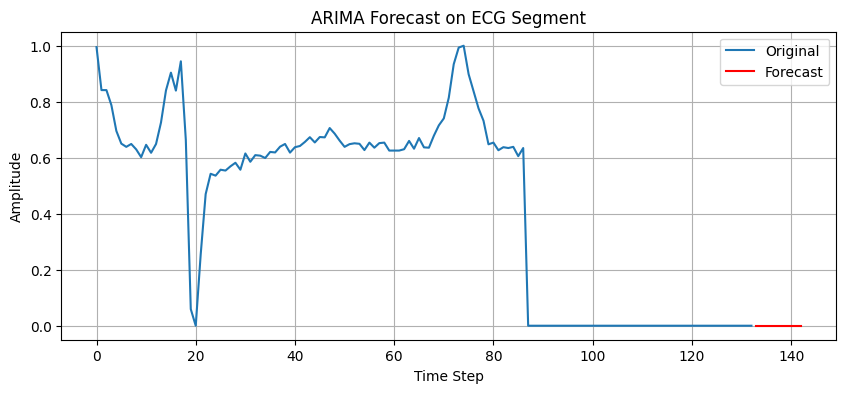

In [4]:
# ==================== FORECAST FUTURE POINTS ====================
n_steps = 10  # Forecast 10 future time steps
forecast = model_fit.forecast(steps=n_steps)

# Plot original + forecast
plt.figure(figsize=(10, 4))
plt.plot(ecg_series, label="Original")
plt.plot(range(len(ecg_series), len(ecg_series) + n_steps), forecast, label="Forecast", color="red")
plt.title("ARIMA Forecast on ECG Segment")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
# ==================== NOTES ====================
# - ARIMA is meant for time series forecasting, not classification.
# - This treats each ECG window as a separate signal.
# - To apply ARIMA across multiple ECGs, loop through samples or consider averaging.
